<a href="https://colab.research.google.com/github/Siphesihle-DEV/Customer-Conversion-Prediction/blob/main/Conversion_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy pandas scikit-learn matplotlib

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported.")


All libraries imported.


In [12]:
#load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/mar-antaya/ml-portfolio-course/main/ecommerce_data.csv')

print(" '(df.head()' prints the first five columns in the dataset) \n")

df.head()

 '(df.head()' prints the first five columns in the dataset) 



,CustomerID,InvoiceDate,Quantity,UnitPrice,TotalAmount,Country,ProductCategory
0,C0045,2022-08-24 00:00:00,2,39.69,79.39,UK,Books
1,C0757,2022-07-01 00:00:00,1,414.09,414.09,Netherlands,Sports
2,C1643,2022-01-05 00:00:00,1,358.44,358.44,NaN,Sports
3,C0133,2023-07-01 00:00:00,1,150.21,150.21,UK,Clothing
4,C0941,2022-12-10 00:00:00,1,222.65,222.65,UK,Sports


In [24]:
print("-----DATA QUALITY CHECK------")
print(f"Tota transactions: {len(df):,}")
print(f"Unique Customers:  {df['CustomerID'].nunique():,}")
print(f"Data Range:        {df['InvoiceDate'].min()} -> {df['InvoiceDate'].max()}")

print(f"\nMissing values")
for col in df.columns:
  missing = df[col].isnull().sum()
  if missing > 0:
    print(f" {col}: {missing}:, missing")

print(f"\nNegative quantities: {(df['Quantity'] <= 0).sum():,}")
print(f"Negative prices:       {(df['UnitPrice'] <= 0).sum():,}")

-----DATA QUALITY CHECK------
Tota transactions: 8,205
Unique Customers:  1,847
Data Range:        2022-01-01 00:00:00 -> 2023-12-31 00:00:00

Missing values
 CustomerID: 16:, missing
 Country: 1339:, missing

Negative quantities: 65
Negative prices:       24


In [76]:
from pandas.io.formats.style_render import Subset
df_clean = df.copy()
print("\n")
print(df_clean)

#convert dates
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

#drop rows where we don't know the customer
df_clean = df_clean.dropna(subset=['CustomerID'])

#Remove returns(Negative or nonzero quantity)
df_clean = df_clean[df_clean['Quantity'] > 0]

#remove returns(bad prices)
df_clean = df_clean[df_clean['UnitPrice'] > 0]

#Create Total Amounts per transaction
if 'TotalAmount' not in df_clean.columns:
  df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Before Cleaning:  {len(df):,} rows")
print(f"After Cleaning: {len(df_clean):,} rows")
print(f"{len(df) - len(df_clean):,} rows were removed after cleaning")
print(f"Clean customers: {df_clean['CustomerID'].nunique():,}")





     CustomerID          InvoiceDate  ...      Country  ProductCategory
0         C0045  2022-08-24 00:00:00  ...           UK            Books
1         C0757  2022-07-01 00:00:00  ...  Netherlands           Sports
2         C1643  2022-01-05 00:00:00  ...          NaN           Sports
3         C0133  2023-07-01 00:00:00  ...           UK         Clothing
4         C0941  2022-12-10 00:00:00  ...           UK           Sports
...         ...                  ...  ...          ...              ...
8200      C0089  2022-11-01 00:00:00  ...           UK           Beauty
8201      C0737  2023-03-06 00:00:00  ...        Spain            Books
8202      C0128  2022-09-19 00:00:00  ...           UK           Beauty
8203      C0388  2022-03-25 00:00:00  ...           UK    Home & Garden
8204      C0940  2022-12-19 00:00:00  ...        Spain           Sports

[8205 rows x 7 columns]
Before Cleaning:  8,205 rows
After Cleaning: 8,100 rows
105 rows were removed after cleaning
Clean customers:

In [67]:
cutoff = df_clean['InvoiceDate'].min() + pd.DateOffset(months=9)
df_features = df_clean[df_clean['InvoiceDate'] <= cutoff].copy()
df_target =df_clean[df_clean['InvoiceDate'] > cutoff].copy()

print(f"Feature window:  {df_features['InvoiceDate'].min().date()} -> {df_features['InvoiceDate'].max().date()}")
print(f"Target window:  {df_target['InvoiceDate'].min().date()} -> {df_target['InvoiceDate'].max().date()}")

feature_date = cutoff + pd.Timedelta(days=1)

rfm = df_features.groupby('CustomerID').agg(
    Recency = ('InvoiceDate', lambda x: (feature_date - x.max()).days),
    Frequency = ('TotalAmount', 'count'),
    Monetary = ('TotalAmount', 'sum')
).round(2)

Feature window:  2022-01-01 -> 2022-10-01
Target window:  2022-10-02 -> 2023-12-31


In [75]:
# Quick summary — what does our customer base look like?
print("=== CUSTOMER BASE SUMMARY ===")
print(f"\nRecency (days since last purchase):")
print(f"  Average: {rfm['Recency'].mean():.0f} days")
print(f"  Most recent: {rfm['Recency'].min()} days ago")
print(f"  Least recent: {rfm['Recency'].max()} days ago")

print(f"\nFrequency (number of purchases):")
print(f"  Average: {rfm['Frequency'].mean():.1f} purchases")
print(f"  Most loyal: {rfm['Frequency'].max()} purchases")

print(f"\nMonetary (total spent):")
print(f"  Average: ${rfm['Monetary'].mean():,.2f}")
print(f"  Highest: ${rfm['Monetary'].max():,.2f}")


=== CUSTOMER BASE SUMMARY ===

Recency (days since last purchase):
  Average: 87 days
  Most recent: 1 days ago
  Least recent: 274 days ago

Frequency (number of purchases):
  Average: 2.6 purchases
  Most loyal: 22 purchases

Monetary (total spent):
  Average: $559.27
  Highest: $4,310.80


In [74]:
# ── Build the target ───────────────────────────────────────
# Did this customer buy in the future window? Yes (1) or No (0)
future_buyers = set(df_target['CustomerID'].unique())
rfm['WillBuyAgain'] = rfm.index.map(lambda x: 1 if x in future_buyers else 0)

print(f"\nRFM table: {len(rfm):,} customers, 3 features each")
print(f"Will buy again:   {rfm['WillBuyAgain'].sum():,} ({rfm['WillBuyAgain'].mean()*100:.0f}%)")
print(f"Won't buy again:  {(rfm['WillBuyAgain'] == 0).sum():,} ({(1 - rfm['WillBuyAgain'].mean())*100:.0f}%)")

print(f"\nSample (first 10 customers):")
rfm.head(10)


RFM table: 1,368 customers, 3 features each
Will buy again:   504 (37%)
Won't buy again:  864 (63%)

Sample (first 10 customers):


,Recency,Frequency,Monetary,WillBuyAgain
CustomerID,,,,
C0001,15,4,421.60,0
C0002,36,2,167.73,1
C0003,3,2,99.65,1
C0005,162,1,68.88,0
C0006,108,1,135.79,0
C0007,202,1,209.35,0
C0011,99,1,33.60,1
C0012,99,1,109.84,0
C0013,157,1,240.28,0


In [73]:
# Separate features (X) and target (y)
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['WillBuyAgain']

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training on: {len(X_train):,} customers")
print(f"Testing on:  {len(X_test):,} customers")

# Train the model — two lines
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)



Training on: 1,094 customers
Testing on:  274 customers


RandomForestClassifier(random_state=42)

In [71]:
# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# How good is our model?
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.1f}%\n")

# Build a results table
results = pd.DataFrame({
    'Recency (days)': X_test['Recency'].values,
    'Frequency': X_test['Frequency'].values,
    'Monetary ($)': X_test['Monetary'].values,
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': (y_prob * 100).round(1)
})

results['Label'] = results['Probability'].apply(
    lambda x: '🟢 Likely' if x >= 50 else '🔴 At Risk'
)

print("=== CUSTOMER PREDICTIONS ===")
print(results.head(15).to_string(index=False))
print(f"\n👆 Every customer scored. The business now knows exactly who to target.")

Model Accuracy: 73.0%

=== CUSTOMER PREDICTIONS ===
 Recency (days)  Frequency  Monetary ($)  Actual  Predicted  Probability     Label
             24          2       1370.04       1          1         72.0  🟢 Likely
            185          2        397.07       0          0          2.0 🔴 At Risk
             28          1        156.62       1          0         13.0 🔴 At Risk
            166          2        919.84       0          0         24.0 🔴 At Risk
            188          1        188.46       0          0         16.0 🔴 At Risk
            252          1        149.10       0          0         10.0 🔴 At Risk
             35          4        701.09       1          1         54.0  🟢 Likely
             14          5       1853.41       1          1         77.0  🟢 Likely
            104          1         30.94       1          0          6.0 🔴 At Risk
             33          2        337.93       0          1         88.0  🟢 Likely
             70          1        2

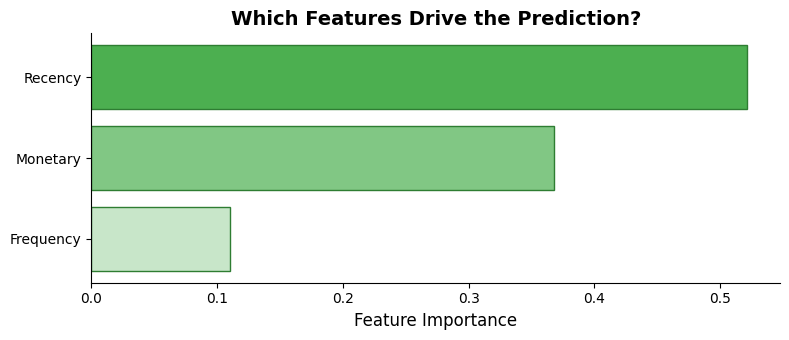

In [72]:
# Which features matter most to the model?
importance = pd.DataFrame({
    'Feature': ['Recency', 'Frequency', 'Monetary'],
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ['#c8e6c9', '#81c784', '#4caf50']
ax.barh(importance['Feature'], importance['Importance'], color=colors, edgecolor='#2e7d32')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Which Features Drive the Prediction?', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
